# 🎨 Notebook 4: Token & Positional Embeddings

**Based on Lectures 10 & 11 from Vizuara AI Series**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand why we need **embeddings**
2. Implement **token embeddings** (content)
3. Implement **positional embeddings** (location)
4. Visualize **embedding spaces**
5. Combine embeddings for **final input representation**

---

## 📚 Table of Contents

1. [The Problem with Integers](#1-the-problem-with-integers)
2. [Token Embeddings (Content)](#2-token-embeddings-content)
3. [Positional Embeddings (Location)](#3-positional-embeddings-location)
4. [Combining Embeddings](#4-combining-embeddings)
5. [Embedding Visualization](#5-embedding-visualization)
6. [Complete Forward Pass](#6-complete-forward-pass)
7. [Key Takeaways](#7-key-takeaways)

In [ ]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import pickle
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ Libraries imported successfully!
PyTorch version: 2.10.0+cpu


### Environment Setup (Colab/Local)

This cell detects whether you're running in Google Colab or locally and sets up the environment accordingly.

In [ ]:
# ========================================
# ENVIRONMENT DETECTION & SETUP
# ========================================

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

# Setup directories
if IN_COLAB:
    # Create necessary directories for Colab
    os.makedirs('data', exist_ok=True)
    os.makedirs('visualizations/tokenization', exist_ok=True)
    os.makedirs('visualizations/embeddings', exist_ok=True)
    os.makedirs('visualizations/data_pipeline', exist_ok=True)
    print("Created directories")
    
    # Set paths for Colab
    DATA_DIR = 'data'
    VIZ_DIR = 'visualizations'
else:
    # Use relative paths for local execution
    DATA_DIR = '../data'
    VIZ_DIR = '../visualizations'
    
    # Create directories if they don't exist (LOCAL FIX)
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/tokenization', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/embeddings', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/data_pipeline', exist_ok=True)
    print(f"Created directories: {DATA_DIR}, {VIZ_DIR}")

print(f"\nData directory: {DATA_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

Running in Google Colab
Created directories

Data directory: data
Visualization directory: visualizations


In [ ]:
# ========================================
# DATA ACQUISITION
# ========================================

sample_path = f'{DATA_DIR}/sample.txt'

# Check if data already exists
if os.path.exists(sample_path):
    print(f"✅ Data file already exists: {sample_path}")
else:
    if IN_COLAB:
        # Download sample data automatically in Colab
        import urllib.request
        
        print("📥 Downloading sample data (Shakespeare text)...")
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        
        try:
            urllib.request.urlretrieve(url, sample_path)
            print(f"✅ Downloaded successfully to {sample_path}")
        except Exception as e:
            print(f"❌ Error downloading file: {e}")
            print("\n💡 Alternative: You can manually upload a text file using:")
            print("   from google.colab import files")
            print("   uploaded = files.upload()")
    else:
        print(f"❌ Error: {sample_path} not found!")
        print(f"\n💡 Please create the file at: {sample_path}")
        print(f"   You can download it from:")
        print(f"   https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt")

# Verify and show stats
if os.path.exists(sample_path):
    with open(sample_path, 'r', encoding='utf-8') as f:
        text_preview = f.read()
    
    print(f"\n📊 File Statistics:")
    print(f"   Total characters: {len(text_preview):,}")
    print(f"   Total lines: {len(text_preview.splitlines()):,}")
    print(f"\n📝 First 200 characters:")
    print(f"   {text_preview[:200]}...")
    print(f"\n✅ Data ready for processing!")

✅ Data file already exists: data/sample.txt

📊 File Statistics:
   Total characters: 1,115,394
   Total lines: 40,000

📝 First 200 characters:
   First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you...

✅ Data ready for processing!


-----

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────┐
# │              EMBEDDING COMBINATION LOGIC                            │
# │                                                                     │
# │  Given: idx with shape (B=4, T=8), n_embd=32                       │
# │                                                                     │
# │  Step 1: Token Embeddings (WHAT is each token?)                    │
# │    token_embedding_table(idx) → (4, 8, 32)                         │
# │    Each token ID gets its own learned vector                       │
# │                                                                     │
# │  Step 2: Positional Embeddings (WHERE is each token?)              │
# │    pos_idx = [0, 1, 2, 3, 4, 5, 6, 7]                              │
# │    position_embedding_table(pos_idx) → (8, 32)                     │
# │    Each position gets its own learned vector                       │
# │                                                                     │
# │  Step 3: Broadcasting Addition                                     │
# │    tok_emb:  (4, 8, 32)  ← batch of token vectors                  │
# │    pos_emb:  (   8, 32)  ← position vectors (same for all batches) │
# │    result:   (4, 8, 32)  ← tok_emb + pos_emb (broadcasted)         │
# │                                                                     │
# │  Broadcasting: pos_emb is automatically repeated for each batch    │
# │  Final: Each token has BOTH content and position information       │
# └─────────────────────────────────────────────────────────────────────┘

# ── Hyperparameters ───────────────────────────────────────────────────
vocab_size  = 65     # updated after data load (character-level)
block_size  = 8      # maximum context length (T)
n_embd      = 32     # embedding dimension (C)
batch_size  = 4      # number of sequences per batch (B)

import torch
import torch.nn as nn

# ── Embedding Tables ──────────────────────────────────────────────────
# Maps each token ID → learned vector of size n_embd
token_embedding_table    = nn.Embedding(vocab_size, n_embd)

# Maps each position index → learned vector of size n_embd
position_embedding_table = nn.Embedding(block_size, n_embd)

def get_embeddings(idx):
    """
    Convert token IDs to embeddings with positional information.
    
    Args:
        idx: Token IDs, shape (B, T)
    
    Returns:
        embeddings: Combined embeddings, shape (B, T, C)
    """
    B, T = idx.shape
    
    # Token embeddings (content: "what is it?")
    # Lookup each token ID in the embedding table
    tok_emb = token_embedding_table(idx)  # (B, T, C)
    
    # Positional embeddings (location: "where is it?")
    # Create position indices [0, 1, 2, ..., T-1]
    pos_idx = torch.arange(T, device=idx.device)  # (T,)
    # Lookup position embeddings
    pos_emb = position_embedding_table(pos_idx)   # (T, C)
    
    # Combine (broadcasting: (B,T,C) + (T,C) → (B,T,C))
    # PyTorch automatically broadcasts pos_emb across the batch dimension
    x = tok_emb + pos_emb
    
    return x, tok_emb, pos_emb

# Test with a batch
test_batch = torch.randint(0, vocab_size, (4, 8))

final_emb, tok_emb, pos_emb = get_embeddings(test_batch)

print(f"📊 Embedding Shapes:")
print(f"Input:              {test_batch.shape}")
print(f"Token embeddings:   {tok_emb.shape}")
print(f"Position embeddings: {pos_emb.shape}")
print(f"Final embeddings:   {final_emb.shape}")

print(f"\n🔍 First token of first sequence:")
print(f"Token ID: {test_batch[0, 0].item()}")
print(f"Token embedding:    {tok_emb[0, 0, :5].detach().numpy()} ...")
print(f"Position embedding: {pos_emb[0, :5].detach().numpy()} ...")
print(f"Final embedding:    {final_emb[0, 0, :5].detach().numpy()} ...")

📊 Embedding Shapes:
Input:              torch.Size([4, 8])
Token embeddings:   torch.Size([4, 8, 32])
Position embeddings: torch.Size([8, 32])
Final embeddings:   torch.Size([4, 8, 32])

🔍 First token of first sequence:
Token ID: 57
Token embedding:    [ 0.6107109   0.21427046 -0.17470814 -1.7561272   1.4259074 ] ...
Position embedding: [-0.53455806 -1.4051521   1.8911963   1.3595442  -0.84876996] ...
Final embedding:    [ 0.07615286 -1.1908816   1.7164881  -0.39658308  0.5771374 ] ...


In [ ]:
# Load data configuration
with open(f'{DATA_DIR}/data_config.pkl', 'rb') as f:
    config = pickle.load(f)

vocab_size = config['vocab_size']
block_size = config['block_size']
batch_size = config['batch_size']
stoi = config['stoi']
itos = config['itos']

print(f"📊 Configuration Loaded:")
print(f"Vocabulary size: {vocab_size}")
print(f"Block size:      {block_size}")
print(f"Batch size:      {batch_size}")

📊 Configuration Loaded:
Vocabulary size: 65
Block size:      8
Batch size:      32


---

## 1. The Problem with Integers

### 🚫 Why Can't We Use Token IDs Directly?

After tokenization, we have sequences of integers:

```python
[18, 47, 56, 1, 12, 33, 72, 0]
```

**Problem 1: Arbitrary Magnitude**
- Token ID 100 vs Token ID 10
- The model might think "100 is 10× larger than 10"
- But these are just labels! "cat" (ID=100) isn't "bigger" than "the" (ID=10)

**Problem 2: No Semantic Relationship**
- Token ID 50 and 51 are numerically close
- But the words they represent might be completely unrelated
- "apple" (50) and "spaceship" (51) have nothing in common!

**Problem 3: Discrete Space**
- Neural networks work with continuous values
- They need smooth gradients to learn
- Integers don't provide this

### 💡 The Solution: Embeddings

**Embeddings** convert discrete tokens into continuous vectors:

```
Token ID (integer) → Dense Vector (floats)
     42            → [0.1, -0.5, 0.9, 0.2, ...]
```

**Key Properties:**
1. **Learnable**: Vectors are updated during training
2. **Dense**: Every dimension has a value (not sparse)
3. **Semantic**: Similar words → Similar vectors
4. **Continuous**: Smooth space for gradient descent

🔢 Token IDs (Discrete):
[ 5 12  3  8 15  3 12  5]

🎨 Embeddings (Continuous):
Shape: torch.Size([8, 4]) (Sequence_Length × Embedding_Dim)
tensor([[-0.4036, -0.4425, -1.2654,  1.4841],
        [ 0.8779,  0.7318,  0.2738,  1.7188],
        [-0.6816,  0.8538,  1.5678, -0.5998],
        [-0.3810, -1.6328, -0.3258,  2.1100],
        [-1.1213,  0.3918, -0.4904, -0.2891],
        [-0.6816,  0.8538,  1.5678, -0.5998],
        [ 0.8779,  0.7318,  0.2738,  1.7188],
        [-0.4036, -0.4425, -1.2654,  1.4841]], grad_fn=<EmbeddingBackward0>)


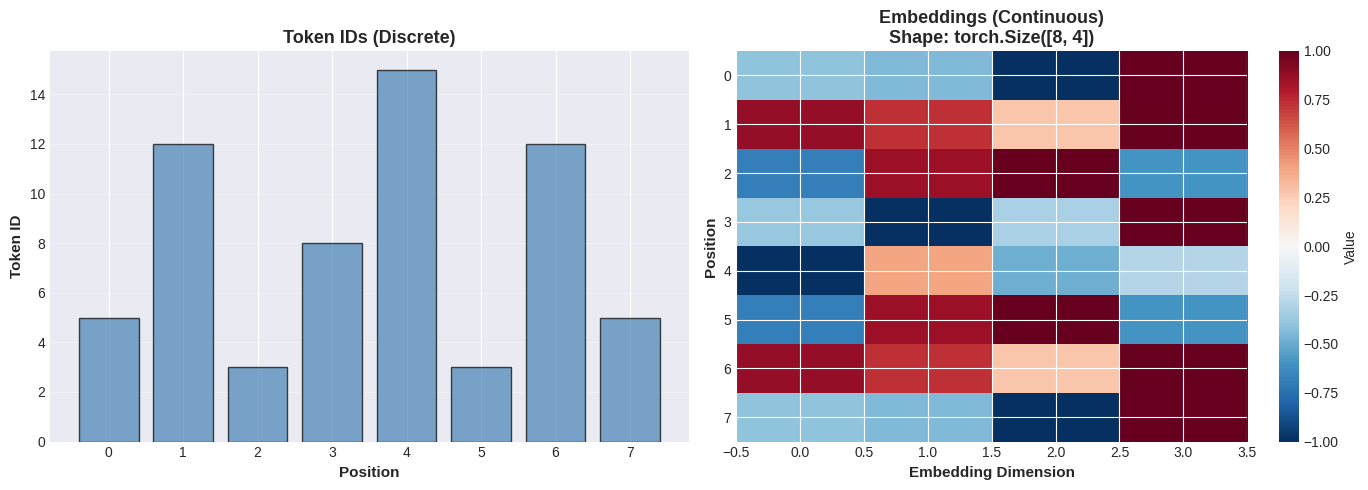


💡 Each token is now represented by a vector of continuous values!


In [ ]:
print("🔢 Token IDs (Discrete):")
print(sample_tokens.numpy())

# Create a simple embedding layer
n_embd = 4  # Small for visualization
# nn.Embedding(20, 4)
# ┌─────┬──────────────────────────────┐
# │ Row │ Vector (4 random values)     │ #Random values, After traning these will turn to be proper weights
# ├─────┼──────────────────────────────┤
# │  0  │ [ 0.12, -0.34,  0.56, -0.78] │
# │  1  │ [-0.23,  0.45, -0.67,  0.89] │
# │  2  │ [ 0.34, -0.56,  0.78, -0.90] │
# │  3  │ [-0.45,  0.67, -0.89,  0.12] │ ← token ID 3  maps here
# │ ... │ ...                          │
# │  5  │ [-0.67,  0.89, -0.12,  0.34] │ ← token ID 5  maps here
# │ ... │ ...                          │
# │ 12  │ [ 0.11, -0.22,  0.33, -0.44] │ ← token ID 12 maps here
# │ ... │ ...                          │
# │ 19  │ [ 0.99, -0.11,  0.22, -0.33] │
# └─────┴──────────────────────────────┘
# all values random at init, learned during training
embedding = nn.Embedding(vocab_size, n_embd)

# Create sample data
sample_tokens = torch.tensor([5, 12, 3, 8, 15, 3, 12, 5])
# Get embeddings
sample_embeddings = embedding(sample_tokens) #→ shape (8, 4)
# ┌─────────┬──────────────────────────────┐
# │ Token   │ Vector (grabbed from table)  │
# ├─────────┼──────────────────────────────┤
# │  5      │ [-0.67,  0.89, -0.12,  0.34] │ ← row 5
# │ 12      │ [ 0.11, -0.22,  0.33, -0.44] │ ← row 12
# │  3      │ [-0.45,  0.67, -0.89,  0.12] │ ← row 3
# │  8      │ [ 0.77, -0.88,  0.99, -0.11] │ ← row 8
# │ 15      │ [-0.55,  0.66, -0.77,  0.88] │ ← row 15
# │  3      │ [-0.45,  0.67, -0.89,  0.12] │ ← row 3  (same as above!)
# │ 12      │ [ 0.11, -0.22,  0.33, -0.44] │ ← row 12 (same as above!)
# │  5      │ [-0.67,  0.89, -0.12,  0.34] │ ← row 5  (same as above!)
# └─────────┴──────────────────────────────┘
# same token ID always → same vector (no position info yet)


print(f"\n🎨 Embeddings (Continuous):")
print(f"Shape: {sample_embeddings.shape} (Sequence_Length × Embedding_Dim)")
print(sample_embeddings)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token IDs
axes[0].bar(range(len(sample_tokens)), sample_tokens.numpy(), color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Position', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Token ID', fontsize=11, fontweight='bold')
axes[0].set_title('Token IDs (Discrete)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Embeddings
im = axes[1].imshow(sample_embeddings.detach().numpy(), cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xlabel('Embedding Dimension', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Position', fontsize=11, fontweight='bold')
axes[1].set_title(f'Embeddings (Continuous)\nShape: {sample_embeddings.shape}', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=axes[1], label='Value')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/discrete_to_continuous.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Each token is now represented by a vector of continuous values!")

---

## 2. Token Embeddings (Content)

### 🎯 What Are Token Embeddings?

Token embeddings answer the question: **"What is this token?"**

They are a **lookup table** (matrix) where:
- Each row = one token in vocabulary
- Each column = one dimension of meaning

### 📐 Dimensions

```
Embedding Matrix Shape: (vocab_size, n_embd)
```

- `vocab_size`: Number of unique tokens (e.g., 65, 50,000, 100,000)
- `n_embd`: Embedding dimension (e.g., 32, 512, 4096, 12288 for GPT-3)

In [ ]:
# Hyperparameters
n_embd = 32  # Embedding dimension (GPT-3 uses 12,288!)

# Create token embedding layer
token_embedding_table = nn.Embedding(vocab_size, n_embd)

print(f"🎨 Token Embedding Table Created!")
print(f"Shape: ({vocab_size}, {n_embd})")
print(f"Total parameters: {vocab_size * n_embd:,}")
print(f"\n📊 Weight matrix:")
print(token_embedding_table.weight.shape)
print(token_embedding_table.weight[:5, :8])  # Show first 5 tokens, 8 dimensions

🎨 Token Embedding Table Created!
Shape: (65, 32)
Total parameters: 2,080

📊 Weight matrix:
torch.Size([65, 32])
tensor([[-0.1993,  0.4683,  1.0864, -0.4892,  1.7520, -0.3744,  0.9508,  1.3072],
        [ 0.8979,  0.6359, -0.8476, -0.0931, -1.2083,  3.1685,  2.2975, -0.1413],
        [-0.3845,  0.6585,  0.7617, -0.6451,  1.6013,  0.3576,  0.0581, -1.0706],
        [-0.1221,  0.1012,  0.4712,  0.6840, -0.7729, -0.3963,  0.5648,  0.3028],
        [ 0.7727, -0.1667, -0.0118, -0.1128,  1.3788,  0.0880, -0.2037,  0.4068]],
       grad_fn=<SliceBackward0>)


### 🔍 How Lookup Works

When we pass a token ID, we get the corresponding row:

In [ ]:
# Example: Look up token ID 42
token_id = torch.tensor([42])
embedding_vector = token_embedding_table(token_id)

print(f"🔍 Lookup Example:")
print(f"Token ID: {token_id.item()}")
print(f"Embedding vector shape: {embedding_vector.shape}")
print(f"Embedding vector:\n{embedding_vector}")

# This is equivalent to:
manual_lookup = token_embedding_table.weight[42]
print(f"\n✅ Manual lookup (same result):")
print(manual_lookup)
print(f"\n🎯 Are they equal? {torch.allclose(embedding_vector.squeeze(), manual_lookup)}")

🔍 Lookup Example:
Token ID: 42
Embedding vector shape: torch.Size([1, 32])
Embedding vector:
tensor([[-0.4187, -0.8159,  0.0169, -1.1842,  0.2747,  1.4315, -0.9009, -0.9459,
          1.2972, -2.0060,  0.2824, -0.8111, -0.1513,  1.4261,  1.1269, -0.8529,
          0.6151, -0.2033, -1.6620,  0.8807,  0.3409, -0.9607, -0.8203,  1.1281,
         -1.1787, -1.1716,  1.6002, -0.3857,  1.3663, -1.4047, -0.5991, -1.4944]],
       grad_fn=<EmbeddingBackward0>)

✅ Manual lookup (same result):
tensor([-0.4187, -0.8159,  0.0169, -1.1842,  0.2747,  1.4315, -0.9009, -0.9459,
         1.2972, -2.0060,  0.2824, -0.8111, -0.1513,  1.4261,  1.1269, -0.8529,
         0.6151, -0.2033, -1.6620,  0.8807,  0.3409, -0.9607, -0.8203,  1.1281,
        -1.1787, -1.1716,  1.6002, -0.3857,  1.3663, -1.4047, -0.5991, -1.4944],
       grad_fn=<SelectBackward0>)

🎯 Are they equal? True


-----

## Positional Embeddings: Why Not Just Use Random Values?

There are two approaches to positional embeddings:

---

### Approach 1: Learned (Random Init) — GPT ✅
```python
# positions start random, model learns what works best
# turns out the model figures out positional patterns on its own
# via backprop - just like token embeddings
position_embedding_table = nn.Embedding(block_size, n_embd)
```

### Approach 2: Fixed (Sine/Cosine) — Original Transformer(mentioned in Attention is all you need Paper)
```python
# positions encoded using sine/cosine waves - NOT learned, mathematically fixed
# pos 0 → [sin(0/1), cos(0/1), sin(0/100), cos(0/100), ...]
# pos 1 → [sin(1/1), cos(1/1), sin(1/100), cos(1/100), ...]
# pos 2 → [sin(2/1), cos(2/1), sin(2/100), cos(2/100), ...]
# guaranteed to be unique and ordered - no training needed
```

### 📌 Comparison

| | Learned | Fixed (Sine/Cosine) |
|---|---|---|
| Init | Random | Mathematically computed |
| Training | Yes, via backprop | No |
| Used In | GPT ✅ | Original Transformer |
| Pros | Model decides what matters | No training needed |

> Both work well in practice. GPT uses **learned** because it's simpler.

---

## Why Sine/Cosine? What Does `sin(0/1), cos(0/1)` Mean?

The goal is simple: **give each position a unique fingerprint** that the model can use to know "where" it is.

---

### ❌ The Problem With Simple Approaches

```python
# Option 1: just use the number itself
# pos 0 → [0]
# pos 1 → [1]
# pos 2 → [2]
# Problem: values get huge for long sequences, hard for model to handle

# Option 2: normalize between 0 and 1
# pos 0 → [0.0]
# pos 1 → [0.1]
# pos 2 → [0.2]
# Problem: values change depending on sequence length, inconsistent
```

---

### ✅ Why Sine/Cosine Works

Think of it like a **clock** — a clock uses circular patterns to encode time uniquely:

```python
# Use multiple sine/cosine waves at different frequencies
# each "column" of the vector is a different wave speed

#           slow wave ──────────────┐  fast wave ─┐
# pos 0 → [sin(0/1),  cos(0/1),    sin(0/100),  cos(0/100)]
# pos 1 → [sin(1/1),  cos(1/1),    sin(1/100),  cos(1/100)]
# pos 2 → [sin(2/1),  cos(2/1),    sin(2/100),  cos(2/100)]
# pos 3 → [sin(3/1),  cos(3/1),    sin(3/100),  cos(3/100)]

# fast wave changes quickly  → distinguishes nearby positions
# slow wave changes slowly   → distinguishes distant positions
# together                   → every position gets a unique vector
```

Visually:
```
fast wave:  0.0, 0.8, 0.9, 0.1, -0.7 ...  (changes a lot between positions)
slow wave:  0.0, 0.0, 0.0, 0.1,  0.1 ...  (barely changes between positions)

combined → each position has a unique combination of both
```

---

### 🕐 Analogy: Binary Clock

It's like representing numbers in binary:
```python
# binary uses multiple columns, each cycling at different speeds:
# pos 0 → [0, 0, 0]
# pos 1 → [0, 0, 1]  ← fast column flips every step
# pos 2 → [0, 1, 0]
# pos 3 → [0, 1, 1]
# pos 4 → [1, 0, 0]  ← slow column flips rarely
#
# sine/cosine is the smooth continuous version of this same idea
```

So `sin(0/1), cos(0/1), sin(0/100), cos(0/100)` just means:
- `/1`   = **fast frequency** (changes quickly across positions)
- `/100` = **slow frequency** (changes slowly across positions)
- Together they guarantee **every position gets a unique vector**


## Positional Embeddings at Inference/Validation Time

### Short Answer: Yes, we reuse the trained values ✅

During training, the positional embedding table gets updated via backprop:
```python
# TRAINING
# position_embedding_table.weight gets updated each step
# e.g. after training:
# pos 0 → [ 0.87, -0.23,  0.45, ...]  ← learned, no longer random
# pos 1 → [-0.12,  0.67, -0.34, ...]  ← learned
# pos 2 → [ 0.34, -0.56,  0.78, ...]  ← learned
# ...
```

At inference, we just reuse those same learned values:
```python
# INFERENCE/VALIDATION (exactly the same code!)
pos_idx = torch.arange(T, device=idx.device)   # [0, 1, 2, ..., T-1]
pos_emb = position_embedding_table(pos_idx)     # fetches learned vectors
# ↑ same lookup, but now weights are trained not random
```

---

### The Flow

```
TRAINING                          INFERENCE
─────────────────────────         ─────────────────────────
random init                       load trained weights
     ↓                                 ↓
forward pass                      forward pass
     ↓                                 ↓
compute loss                      get prediction
     ↓                                 ↑
backprop                          same position_embedding_table
     ↓                            but weights are now meaningful
update weights          ──────►   (not random anymore)
     ↓
repeat millions of times
```

---

### Key Point

```python
# position_embedding_table is part of the MODEL
# when you save/load the model, positional embeddings come with it

torch.save(model.state_dict(), 'model.pt')   # saves everything including pos embeddings
model.load_state_dict(torch.load('model.pt')) # loads everything back

# so at inference:
# pos 0 always → same learned vector (not random anymore)
# pos 1 always → same learned vector
# ...
```

> The positional embedding table is just weights like any other —  
> **trained once, reused forever at inference.**

---

## 3. Positional Embeddings (Location)

### 🚨 The Critical Problem

**Token embeddings alone are NOT enough!**

Consider these two sentences:
1. "The cat ate the mouse"
2. "The mouse ate the cat"

After token embedding, both sentences have the **same set of vectors** (just in different order).

But the **meaning is completely different**!

### 💡 The Solution: Positional Embeddings

Positional embeddings answer: **"Where is this token in the sequence?"**

They inject information about **position** into the model.

In [ ]:
# Create positional embedding layer
position_embedding_table = nn.Embedding(block_size, n_embd)
# position_embedding_table = nn.Embedding(block_size=8, n_embd=32)
# maps each POSITION INDEX to a learned vector (not token ID)
#
# ┌──────────┬─────────────────────────────────────────┐
# │ Position │ Vector (32 random values)               │
# ├──────────┼─────────────────────────────────────────┤
# │    0     │ [ 0.12, -0.34,  0.56, ... -0.78]        │ ← 1st token in sequence
# │    1     │ [-0.23,  0.45, -0.67, ...  0.89]        │ ← 2nd token in sequence
# │    2     │ [ 0.34, -0.56,  0.78, ... -0.90]        │ ← 3rd token in sequence
# │    3     │ [-0.45,  0.67, -0.89, ...  0.12]        │ ← 4th token in sequence
# │    4     │ [ 0.56, -0.78,  0.90, ... -0.23]        │ ← 5th token in sequence
# │    5     │ [-0.67,  0.89, -0.12, ...  0.34]        │ ← 6th token in sequence
# │    6     │ [ 0.11, -0.22,  0.33, ... -0.44]        │ ← 7th token in sequence
# │    7     │ [-0.55,  0.66, -0.77, ...  0.88]        │ ← 8th token in sequence
# └──────────┴─────────────────────────────────────────┘
# all values random at init, learned during training
# unlike token embeddings, input is always [0,1,2,3,4,5,6,7] (position indices)

print(f"📍 Positional Embedding Table Created!")
print(f"Shape: ({block_size}, {n_embd})")
print(f"Total parameters: {block_size * n_embd:,}")
print(f"\n📊 Weight matrix:")
print(position_embedding_table.weight.shape)
print(position_embedding_table.weight[:5, :8])  # Show first 5 positions

📍 Positional Embedding Table Created!
Shape: (8, 32)
Total parameters: 256

📊 Weight matrix:
torch.Size([8, 32])
tensor([[-0.4434, -1.7999, -0.4873, -0.3602, -0.8538,  0.0042,  1.1945,  0.4832],
        [-0.9697,  0.3141,  1.2000, -0.1832,  0.4256,  0.5940, -0.7561, -0.4374],
        [-0.5290,  0.9325,  0.6762,  0.1438, -0.5372, -1.0256,  0.3165, -0.7055],
        [-0.9809, -0.7520, -1.0325, -1.8080,  0.8106, -0.8081,  0.5223, -0.9891],
        [-0.2384, -0.6827,  0.4621, -0.9165,  0.0817,  0.5295, -0.5031, -1.2538]],
       grad_fn=<SliceBackward0>)


---

## 4. Combining Embeddings

### 🎯 The Magic: Addition

We combine token and positional embeddings by **simple addition**:

```python
final_embedding = token_embedding + positional_embedding
```

**Why addition works:**
- Both are in the same vector space (same dimension)
- The model learns to use both sources of information
- Mathematically elegant and computationally efficient


## Token + Positional Embedding: Addition NOT Concatenation

### ❌ What you might think (Concatenation)
```python
token_embedding     shape: (8, 32)
positional_embedding shape: (8, 32)

concatenate → (8, 64)  ← dimensions grow!
# stacking vectors end to end
# [tok_dim1, tok_dim2, ..., tok_dim32, pos_dim1, pos_dim2, ..., pos_dim32]
```

### ✅ What actually happens (Addition)
```python
token_embedding      shape: (8, 32)
positional_embedding shape: (8, 32)

addition → (8, 32)  ← same dimensions!
# adding values at each position
# [tok_dim1+pos_dim1, tok_dim2+pos_dim2, ..., tok_dim32+pos_dim32]
```

### Visually
```
token_emb:  [ 0.5,  0.3, -0.2,  0.8]   ← "what is this token?"
pos_emb:    [ 0.1, -0.4,  0.7,  0.2]   ← "where is this token?"
            ──────────────────────────
final:      [ 0.6, -0.1,  0.5,  1.0]   ← "what AND where"
              ↑
              0.5 + 0.1 = 0.6  (element-wise addition)
```

### Why Addition Works
```
- Both embeddings are in the SAME vector space (same n_embd dimensions)
- Model learns to encode token info and position info
  such that they can be simply added together
- The model untangles them internally during attention
- Keeps dimensions small (32) vs concatenation (64)


## How Can Position Info Be Added to Token Features?

### Your Intuition About Token Embeddings (Correct! ✅)
```python
# After training, token embedding dimensions MIGHT encode things like:
# token "king" → [ 0.9,  0.2,  0.8, -0.4]
#                  ↑     ↑     ↑     ↑
#                royalty male  noun  positive_sentiment
#
# token "queen" → [ 0.9,  0.8,  0.8, -0.4]
#                   ↑     ↑     ↑     ↑
#                royalty female noun  positive_sentiment
```

### But Here's The Key Thing 🔑
```python
# We (humans) don't decide what each dimension means
# The MODEL decides during training
#
# We just say: "here are 32 numbers per token, figure it out"
# The model learns to pack BOTH token AND position info
# into those same 32 numbers in a way that works best
```

### How Addition Works Then
```python
# Think of it as "blending" not "separating"
# 
# token_emb:  [ 0.9,  0.2,  0.8, -0.4]  ← encodes "king"
# pos_emb:    [ 0.1, -0.1,  0.0,  0.2]  ← encodes "position 3"
# final:      [ 1.0,  0.1,  0.8, -0.2]  ← encodes "king at position 3"
#
# The model learns:
# - token embeddings that LEAVE ROOM for position info to be added
# - position embeddings that SLOT INTO that room
# They co-adapt during training to work together
```

### Analogy: RGB Colours
```
Imagine colour as a vector:
red   = [255,   0,   0]
tint  = [ 20,  20,  20]  ← "brightness at this position"
final = [275,  20,  20]  ← still recognisably red, but with brightness info baked in

The model does the same thing but in 32 dimensions
and it learns what "tint" to add for each position
```

### Why Not Concatenation Then?
```python
# Concatenation would be cleaner conceptually:
# [king_features | position_3_features] → (64,)
# token and position info never "mix"

# But addition is used because:
# 1. keeps dimensions small (32 not 64)
# 2. model is powerful enough to untangle them
# 3. works just as well in practice (empirically proven)
# 4. GPT, BERT all use addition - its the standard
```

```

In [ ]:
def get_embeddings(idx):
    """
    Convert token IDs to embeddings with positional information.
    
    Args:
        idx: Token IDs, shape (B, T)
    
    Returns:
        embeddings: Combined embeddings, shape (B, T, C)
    """
    B, T = idx.shape
    
    # Token embeddings (content: "what is it?")
    tok_emb = token_embedding_table(idx)  # (B, T, C)
    
    # Positional embeddings (location: "where is it?")
    pos_idx = torch.arange(T, device=idx.device)  # (T,)
    pos_emb = position_embedding_table(pos_idx)   # (T, C)
    
    # Combine (broadcasting: (B,T,C) + (T,C) → (B,T,C))
    x = tok_emb + pos_emb
    
    return x, tok_emb, pos_emb

# Test with a batch
test_batch = torch.randint(0, vocab_size, (4, 8))

final_emb, tok_emb, pos_emb = get_embeddings(test_batch)

print(f"📊 Embedding Shapes:")
print(f"Input:              {test_batch.shape}")
print(f"Token embeddings:   {tok_emb.shape}")
print(f"Position embeddings: {pos_emb.shape}")
print(f"Final embeddings:   {final_emb.shape}")

print(f"\n🔍 First token of first sequence:")
print(f"Token ID: {test_batch[0, 0].item()}")
print(f"Token embedding:    {tok_emb[0, 0, :5].detach().numpy()} ...")
print(f"Position embedding: {pos_emb[0, :5].detach().numpy()} ...")
print(f"Final embedding:    {final_emb[0, 0, :5].detach().numpy()} ...")

📊 Embedding Shapes:
Input:              torch.Size([4, 8])
Token embeddings:   torch.Size([4, 8, 32])
Position embeddings: torch.Size([8, 32])
Final embeddings:   torch.Size([4, 8, 32])

🔍 First token of first sequence:
Token ID: 54
Token embedding:    [-0.2280528  -0.9480227  -0.15365808  1.0321265   0.3685239 ] ...
Position embedding: [-0.4433964  -1.7998695  -0.48732024 -0.3601966  -0.8537927 ] ...
Final embedding:    [-0.6714492  -2.7478924  -0.64097834  0.67192996 -0.48526883] ...


---

## 5. Complete Embedding Layer

Let's create a complete embedding module:

In [ ]:
class EmbeddingLayer(nn.Module):
    """
    Complete embedding layer with token and positional embeddings.
    
    Args:
        vocab_size: Size of vocabulary
        block_size: Maximum sequence length
        n_embd: Embedding dimension
    """
    
    def __init__(self, vocab_size, block_size, n_embd):
        super().__init__()
        
        # Token embeddings (content)
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        
        # Positional embeddings (location)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        
        self.block_size = block_size
    
    def forward(self, idx):
        """
        Args:
            idx: Token IDs, shape (B, T)
        
        Returns:
            x: Embeddings, shape (B, T, C)
        """
        B, T = idx.shape
        
        # Token embeddings
        tok_emb = self.token_embedding_table(idx)  # (B, T, C)
        
        # Positional embeddings
        pos = torch.arange(T, device=idx.device)   # (T,)
        pos_emb = self.position_embedding_table(pos)  # (T, C)
        
        # Combine
        x = tok_emb + pos_emb  # (B, T, C)
        
        return x

# Create the module
embedding_layer = EmbeddingLayer(vocab_size, block_size, n_embd)

print(f"🎨 Embedding Layer Created!")
print(f"\n📊 Parameters:")
print(f"Token embeddings:    {vocab_size} × {n_embd} = {vocab_size * n_embd:,}")
print(f"Position embeddings: {block_size} × {n_embd} = {block_size * n_embd:,}")
print(f"Total parameters:    {(vocab_size + block_size) * n_embd:,}")

# Test the module
test_batch = torch.randint(0, vocab_size, (4, 8))
output = embedding_layer(test_batch)

print(f"\n📥 Input shape: {test_batch.shape}")
print(f"📤 Output shape: {output.shape}")
print(f"\n✅ Embedding layer is ready for the Transformer!")

🎨 Embedding Layer Created!

📊 Parameters:
Token embeddings:    65 × 32 = 2,080
Position embeddings: 8 × 32 = 256
Total parameters:    2,336

📥 Input shape: torch.Size([4, 8])
📤 Output shape: torch.Size([4, 8, 32])

✅ Embedding layer is ready for the Transformer!


---

## 6. Key Takeaways

### ✅ What We Learned

1. **Why Embeddings?**
   - Integers are arbitrary and discrete
   - Neural networks need continuous, semantic representations
   - Embeddings provide smooth gradient space

2. **Token Embeddings (Content)**
   - Lookup table: (vocab_size, n_embd)
   - Each token → Dense vector
   - Learnable parameters updated during training
   - Answers: "What is this token?"

3. **Positional Embeddings (Location)**
   - Lookup table: (block_size, n_embd)
   - Each position → Dense vector
   - Critical for understanding word order
   - Answers: "Where is this token?"

4. **Combining Embeddings**
   - Simple addition: `tok_emb + pos_emb`
   - Both sources of information in one vector
   - Elegant and efficient

5. **Shape Transformations**
   ```
   Input:  (B, T)       → Token IDs
   Output: (B, T, C)    → Embedding vectors
   
   Where:
     B = Batch size
     T = Sequence length
     C = Embedding dimension
   ```

### 🔮 What's Next?

In **Notebook 5**, we'll implement the **Self-Attention Mechanism**:
- How tokens "communicate" with each other
- Query, Key, Value matrices
- Attention scores and weighted aggregation
- The core innovation of Transformers!

In [ ]:
# Save the embedding layer
torch.save({
    'embedding_layer': embedding_layer.state_dict(),
    'vocab_size': vocab_size,
    'block_size': block_size,
    'n_embd': n_embd
}, f'{DATA_DIR}/embedding_layer.pth')

print("✅ Embedding layer saved to f'{DATA_DIR}/embedding_layer.pth'")

✅ Embedding layer saved to f'{DATA_DIR}/embedding_layer.pth'
